# Growth — 학교 40명 도달 및 확산 유형

## 공통 기준
- 현재 네트워크 스냅샷의 일반 계정(운영·관리 계정 제외)을 사용자 ID로 중복 제거합니다.
- 학교 ID는 현재 스냅샷의 학교입니다. 과거 전학·탈퇴 이력까지 복원한 모집단은 아닙니다.
- D0는 이 모집단의 누적 가입자가 처음 40명에 도달한 날짜입니다. 실제 기능 활성화 로그 시점과 구분합니다.
- 확산 유형은 2023년 4~5월 D0 도달 학교에서 D+1~7, D+8~14 가입자 수의 각각 중앙값으로 분류합니다.
- 최초 가입 후 7·14일과 D0 전후 구간은 서로 다른 시간 기준입니다.
- 유형은 사후 구간으로 분류한 기술 통계입니다. 예측 변수나 인과 효과로 해석하지 않습니다.
- 원본과 동일하게 가입 기록이 없는 학교·일은 0명으로 처리합니다. 추출 범위 밖의 기간을 무가입으로 간주하지 않도록 원본 데이터의 관찰기간을 확인해야 합니다.

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
import seaborn as sns
from IPython.display import display

# 기본 구조: 같은 상위 폴더 아래 team7/ 와 team7_marts/
# 다른 위치면 이 한 줄에 실제 폴더 경로를 입력합니다.
DATA_DIR_OVERRIDE = os.environ.get("TEAM7_MARTS_DIR", "")
if DATA_DIR_OVERRIDE:
    data_dir = Path(DATA_DIR_OVERRIDE).expanduser().resolve()
else:
    current = Path.cwd().resolve()
    candidates = []
    for parent in [current, *current.parents]:
        candidates.extend([parent / "team7_marts", parent.parent / "team7_marts"])
    data_dir = next((p for p in candidates if p.is_dir()), None)
    if data_dir is None:
        raise FileNotFoundError("team7_marts 폴더가 없습니다. DATA_DIR_OVERRIDE에 실제 폴더 경로를 입력하세요.")
if not data_dir.is_dir():
    raise FileNotFoundError(f"데이터 폴더가 없습니다: {data_dir}")
print("데이터 폴더:", data_dir)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
fonts = {f.name for f in font_manager.fontManager.ttflist}
for font in ["AppleGothic", "Malgun Gothic", "NanumGothic", "Noto Sans CJK KR"]:
    if font in fonts:
        plt.rcParams["font.family"] = font
        break
plt.rcParams["axes.unicode_minus"] = False

def read_mart(filename, required):
    path = data_dir / filename
    if not path.is_file():
        raise FileNotFoundError(f"필요한 마트가 없습니다: {path}")
    frame = pd.read_csv(path, low_memory=False, na_values=[r"\N"])
    missing = sorted(set(required) - set(frame.columns))
    if missing:
        raise ValueError(f"{filename}: 필수 컬럼 누락 {missing}")
    return frame

network = read_mart("mart_user_network_snapshot.csv", [
    "user_id", "school_id", "user_created_at", "is_staff", "is_superuser"
])
for column in ["is_staff", "is_superuser"]:
    network[column] = pd.to_numeric(network[column], errors="coerce")

데이터 폴더: /Users/jangjunyoung/DA15_Part4/team7_marts


In [2]:
# ============================================================
# 2. 분석용 사용자 데이터 정리
# ============================================================

users = network.copy()

# 관리자·운영 계정 제외
users = users[
    users["is_superuser"].fillna(0).eq(0)
    & users["is_staff"].fillna(0).eq(0)
].copy()

# 자료형 변환
users["school_id"] = pd.to_numeric(
    users["school_id"],
    errors="coerce"
)

users["user_id"] = pd.to_numeric(
    users["user_id"],
    errors="coerce"
)

users["user_created_at"] = pd.to_datetime(
    users["user_created_at"],
    errors="coerce"
)

# 분석 필수값이 없는 행 제외
users = users.dropna(
    subset=["user_id", "school_id", "user_created_at"]
).copy()

users["user_id"] = users["user_id"].astype("int64")
users["school_id"] = users["school_id"].astype("int64")
users["signup_date"] = users["user_created_at"].dt.normalize()
users["signup_month"] = (
    users["signup_date"]
    .dt.to_period("M")
    .astype(str)
)

# 사용자 중복 제거
users = (
    users
    .sort_values("user_created_at")
    .drop_duplicates("user_id", keep="first")
    .reset_index(drop=True)
)

print("분석 사용자 수:", f"{users['user_id'].nunique():,}명")
print("분석 학교 수:", f"{users['school_id'].nunique():,}개")
print(
    "가입일 범위:",
    users["signup_date"].min(),
    "~",
    users["signup_date"].max()
)

display(users.head())

분석 사용자 수: 677,080명
분석 학교 수: 5,551개
가입일 범위: 2023-03-29 00:00:00 ~ 2024-05-09 00:00:00


,mart_built_at,user_id,gender,user_created_at,is_superuser,is_staff,ban_status,group_id,grade,class_num,school_id,school_address,school_type,student_count,current_friend_count_snapshot,network_degree_count,mutual_friend_count,one_way_friend_count,valid_outbound_listing_count,valid_inbound_listing_count,same_school_friend_count,same_grade_friend_count,same_group_friend_count,unknown_school_relation_count,orphan_friend_reference_count,duplicate_friend_reference_count,is_isolated_current_snapshot,is_isolated_valid_network,is_inbound_only_user,reciprocity_rate,same_school_friend_rate,same_group_friend_rate,degree_centrality,sent_request_count,sent_accepted_count,sent_pending_count,sent_rejected_count,received_request_count,received_accepted_count,received_pending_count,received_rejected_count,total_request_activity_count,accepted_request_record_count,pending_request_record_count,rejected_request_record_count,accepted_request_partner_count,has_accepted_request_partner,repeated_accepted_request_count,sent_acceptance_rate,received_acceptance_rate,sent_decision_acceptance_rate,received_decision_acceptance_rate,network_status,request_status,signup_date,signup_month
0,2026-09-02 00:47:38.728474,831962,F,2023-03-29 05:18:56.162368,0,0,N,12.00,2.00,1.00,1,NaN,NaN,NaN,43,31,31,0,31,31,25,2,0,0,12,0,0,0,0,1.00,0.81,0.00,0.00,1,1,0,0,26,0,26,0,27,1,26,0,1,1,0,1.00,0.00,1.00,NaN,FULLY_RECIPROCAL,HAS_ACCEPTED_PARTNER,2023-03-29,2023-03
1,2026-09-02 00:47:38.728474,832151,M,2023-03-29 12:56:34.989468,0,0,N,1.00,1.00,1.00,1,NaN,NaN,NaN,51,50,50,0,50,50,45,35,32,0,1,0,0,0,0,1.00,0.90,0.64,0.00,10,2,8,0,35,6,29,0,45,8,37,0,8,1,0,0.20,0.17,1.00,1.00,FULLY_RECIPROCAL,HAS_ACCEPTED_PARTNER,2023-03-29,2023-03
2,2026-09-02 00:47:38.728474,832340,F,2023-03-29 12:56:35.020790,0,0,N,1.00,1.00,1.00,1,NaN,NaN,NaN,57,56,56,0,56,56,51,36,32,0,1,0,0,0,0,1.00,0.91,0.57,0.00,26,7,19,0,25,4,21,0,51,11,40,0,11,1,0,0.27,0.16,1.00,1.00,FULLY_RECIPROCAL,HAS_ACCEPTED_PARTNER,2023-03-29,2023-03
3,2026-09-02 00:47:38.728474,832520,M,2023-03-29 12:56:35.049311,0,0,N,12.00,2.00,1.00,1,NaN,NaN,NaN,18,17,17,0,17,17,12,3,2,0,1,0,0,0,0,1.00,0.71,0.12,0.00,0,0,0,0,14,0,14,0,14,0,14,0,0,0,0,NaN,0.00,NaN,NaN,FULLY_RECIPROCAL,REQUEST_WITHOUT_ACCEPTED_PARTNER,2023-03-29,2023-03
4,2026-09-02 00:47:38.728474,832614,M,2023-03-29 12:56:35.064406,0,0,N,12.00,2.00,1.00,1,NaN,NaN,NaN,21,20,20,0,20,20,16,6,4,0,1,0,0,0,0,1.00,0.80,0.20,0.00,0,0,0,0,12,0,12,0,12,0,12,0,0,0,0,NaN,0.00,NaN,NaN,FULLY_RECIPROCAL,REQUEST_WITHOUT_ACCEPTED_PARTNER,2023-03-29,2023-03


# 40명 도달 여부 분석

In [3]:
# ============================================================
# 4. 학교별 40명 도달 여부 및 도달일 계산
# ============================================================

# 학교별 일별 신규 가입자
school_daily_signup = (
    users
    .groupby(["school_id", "signup_date"])["user_id"]
    .nunique()
    .rename("일별가입자수")
    .reset_index()
    .sort_values(["school_id", "signup_date"])
)

# 학교별 누적 가입자
school_daily_signup["누적가입자수"] = (
    school_daily_signup
    .groupby("school_id")["일별가입자수"]
    .cumsum()
)

# 학교별 최초 가입일
school_first_signup = (
    school_daily_signup
    .groupby("school_id")["signup_date"]
    .min()
    .rename("최초가입일")
    .reset_index()
)

# 학교별 40명 최초 도달일
school_reach_40 = (
    school_daily_signup[
        school_daily_signup["누적가입자수"] >= 40
    ]
    .groupby("school_id")["signup_date"]
    .min()
    .rename("40명_도달일")
    .reset_index()
)

# 학교별 최종 가입자 수
school_final_users = (
    users
    .groupby("school_id")["user_id"]
    .nunique()
    .rename("최종가입자수")
    .reset_index()
)

# 학교 단위 데이터 결합
school_activation = (
    school_first_signup
    .merge(
        school_reach_40,
        on="school_id",
        how="left"
    )
    .merge(
        school_final_users,
        on="school_id",
        how="left"
    )
)

school_activation["40명_도달여부"] = np.where(
    school_activation["40명_도달일"].notna(),
    "40명 도달",
    "40명 미도달"
)

school_activation["40명_도달소요일"] = (
    school_activation["40명_도달일"]
    - school_activation["최초가입일"]
).dt.days + 1

print("전체 학교 수:", f"{school_activation['school_id'].nunique():,}개")

display(
    school_activation["40명_도달여부"]
    .value_counts()
    .rename_axis("도달구분")
    .reset_index(name="학교수")
)

display(school_activation.head())

전체 학교 수: 5,551개


,도달구분,학교수
0,40명 도달,3897
1,40명 미도달,1654


,school_id,최초가입일,40명_도달일,최종가입자수,40명_도달여부,40명_도달소요일
0,1,2023-03-29,2023-04-29,93,40명 도달,32.00
1,4,2023-05-08,2023-05-12,235,40명 도달,5.00
2,5,2023-05-07,2023-05-13,160,40명 도달,7.00
3,6,2023-05-01,2023-05-12,197,40명 도달,12.00
4,7,2023-04-23,2023-05-13,114,40명 도달,21.00


# 초기 가입 속도 비교(40명 도달 학교와 미도달 학교)

In [4]:
# ============================================================
# 5. 학교별 초기 7일·14일 가입자 계산
# ============================================================

# 사용자 가입 데이터에 학교 최초 가입일 결합
school_signup = users[
    ["school_id", "user_id", "signup_date"]
].merge(
    school_first_signup,
    on="school_id",
    how="left"
)

# 학교 최초 가입일 기준 경과 일수
school_signup["최초가입후_경과일"] = (
    school_signup["signup_date"]
    - school_signup["최초가입일"]
).dt.days

# 학교별 초기 가입 지표
initial_signup = (
    school_signup
    .groupby("school_id")
    .agg(
        초기7일가입자=(
            "최초가입후_경과일",
            lambda x: x.between(0, 6).sum()
        ),
        초기14일가입자=(
            "최초가입후_경과일",
            lambda x: x.between(0, 13).sum()
        ),
        가입발생일수=("signup_date", "nunique")
    )
    .reset_index()
)

# 기존 학교 활성화 데이터와 결합
school_activation = school_activation.merge(
    initial_signup,
    on="school_id",
    how="left"
)

# 도달 여부별 비교
reach_comparison = (
    school_activation
    .groupby("40명_도달여부")
    .agg(
        학교수=("school_id", "nunique"),
        초기7일가입자_평균=("초기7일가입자", "mean"),
        초기7일가입자_중앙값=("초기7일가입자", "median"),
        초기14일가입자_평균=("초기14일가입자", "mean"),
        초기14일가입자_중앙값=("초기14일가입자", "median"),
        가입발생일수_평균=("가입발생일수", "mean"),
        최종가입자수_평균=("최종가입자수", "mean"),
        최종가입자수_중앙값=("최종가입자수", "median")
    )
    .reset_index()
)

display(reach_comparison)

,40명_도달여부,학교수,초기7일가입자_평균,초기7일가입자_중앙값,초기14일가입자_평균,초기14일가입자_중앙값,가입발생일수_평균,최종가입자수_평균,최종가입자수_중앙값
0,40명 도달,3897,56.42,20.00,108.67,94.00,20.94,168.21,154.00
1,40명 미도달,1654,5.43,3.00,8.35,5.00,7.01,13.05,11.00


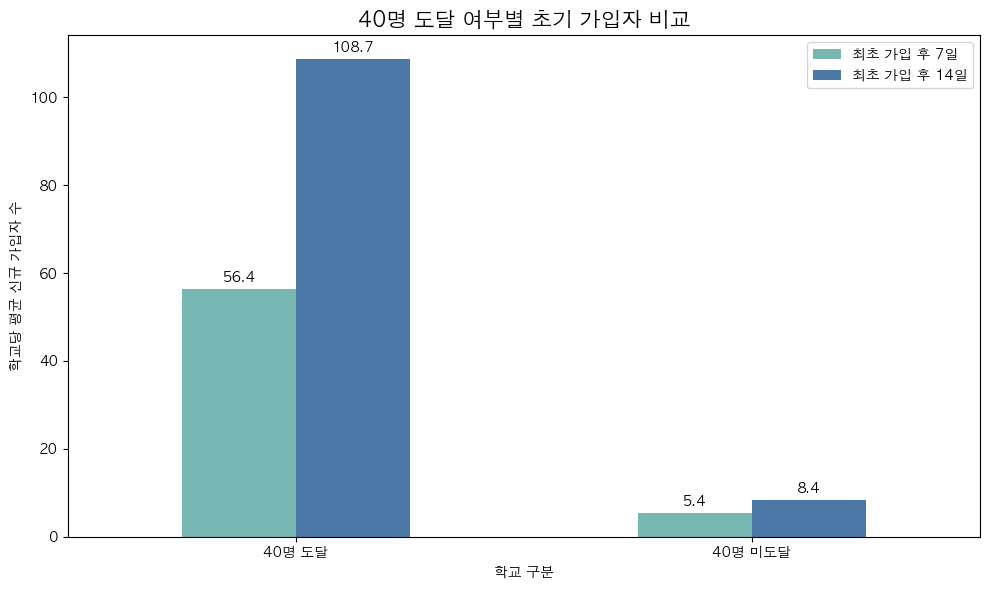

In [5]:
# ============================================================
# 5-1. 40명 도달 여부별 초기 가입자 시각화
# ============================================================

plot_data = reach_comparison.set_index("40명_도달여부")

ax = plot_data[
    ["초기7일가입자_평균", "초기14일가입자_평균"]
].plot(
    kind="bar",
    figsize=(10, 6),
    color=["#76B7B2", "#4C78A8"]
)

plt.title(
    "40명 도달 여부별 초기 가입자 비교",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("학교 구분")
plt.ylabel("학교당 평균 신규 가입자 수")
plt.xticks(rotation=0)
plt.legend(["최초 가입 후 7일", "최초 가입 후 14일"])

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f",
        padding=3
    )

plt.tight_layout()
plt.show()

# 40명 도달일을 D0로 설정하고 전후 14일의 가입 흐름 확인

In [6]:
# ============================================================
# 6. 40명 도달일(D0) 기준 상대 일자 생성
# ============================================================

# 2023년 4~5월에 40명에 도달한 학교만 선택
viral_reached_schools = school_activation[
    school_activation["40명_도달일"].between(
        pd.Timestamp("2023-04-01"),
        pd.Timestamp("2023-05-31")
    )
][
    ["school_id", "40명_도달일"]
].copy()

print(
    "4~5월 40명 도달 학교:",
    f"{viral_reached_schools['school_id'].nunique():,}개"
)

# 학교별 일별 가입 데이터에 D0 결합
event_signup = school_daily_signup.merge(
    viral_reached_schools,
    on="school_id",
    how="inner"
)

# D0 기준 상대 일자
event_signup["relative_day"] = (
    event_signup["signup_date"]
    - event_signup["40명_도달일"]
).dt.days

# D-14부터 D+14까지만 사용
event_signup = event_signup[
    event_signup["relative_day"].between(-14, 14)
].copy()

display(event_signup.head())

4~5월 40명 도달 학교: 3,796개


,school_id,signup_date,일별가입자수,누적가입자수,40명_도달일,relative_day
3,1,2023-04-15,3,18,2023-04-29,-14
4,1,2023-04-17,2,20,2023-04-29,-12
5,1,2023-04-19,2,22,2023-04-29,-10
6,1,2023-04-20,1,23,2023-04-29,-9
7,1,2023-04-21,1,24,2023-04-29,-8


In [7]:
# ============================================================
# 6-1. 학교별 D-14~D+14 날짜 균형 맞추기
# ============================================================

school_ids = viral_reached_schools["school_id"].unique()
relative_days = np.arange(-14, 15)

# 모든 학교 × 29일 조합 생성
balanced_school_day = pd.MultiIndex.from_product(
    [school_ids, relative_days],
    names=["school_id", "relative_day"]
).to_frame(index=False)

# 실제 가입자 수 결합
balanced_school_day = balanced_school_day.merge(
    event_signup[
        ["school_id", "relative_day", "일별가입자수"]
    ],
    on=["school_id", "relative_day"],
    how="left"
)

# 가입 기록이 없는 날짜는 0명
balanced_school_day["일별가입자수"] = (
    balanced_school_day["일별가입자수"]
    .fillna(0)
)

print(
    "분석 학교 수:",
    f"{balanced_school_day['school_id'].nunique():,}개"
)

print(
    "학교·일 데이터 수:",
    f"{len(balanced_school_day):,}행"
)

display(balanced_school_day.head())

분석 학교 수: 3,796개
학교·일 데이터 수: 110,084행


,school_id,relative_day,일별가입자수
0,1,-14,3.00
1,1,-13,0.00
2,1,-12,2.00
3,1,-11,0.00
4,1,-10,2.00


In [8]:
# ============================================================
# 6-2. D0 기준 일별 확산 곡선
# ============================================================

event_curve = (
    balanced_school_day
    .groupby("relative_day")
    .agg(
        일평균_신규가입자=("일별가입자수", "mean"),
        중앙값_신규가입자=("일별가입자수", "median"),
        가입발생_학교수=(
            "일별가입자수",
            lambda x: (x > 0).sum()
        ),
        일별_최대가입자=("일별가입자수", "max")
    )
    .reset_index()
)

# 전체 분석 학교 수
reached_school_count = (
    viral_reached_schools["school_id"]
    .nunique()
)

# 일별 가입 발생 학교 비율
event_curve["가입발생_학교비율(%)"] = (
    event_curve["가입발생_학교수"]
    / reached_school_count
    * 100
)

# 소수점 정리
event_curve["일평균_신규가입자"] = (
    event_curve["일평균_신규가입자"]
    .round(2)
)

event_curve["중앙값_신규가입자"] = (
    event_curve["중앙값_신규가입자"]
    .round(2)
)

event_curve["가입발생_학교비율(%)"] = (
    event_curve["가입발생_학교비율(%)"]
    .round(2)
)

display(event_curve)

,relative_day,일평균_신규가입자,중앙값_신규가입자,가입발생_학교수,일별_최대가입자,가입발생_학교비율(%)
0,-14,0.21,0.00,397,15.00,10.46
1,-13,0.23,0.00,419,20.00,11.04
2,-12,0.29,0.00,496,19.00,13.07
3,-11,0.35,0.00,554,21.00,14.59
4,-10,0.38,0.00,637,25.00,16.78
5,-9,0.49,0.00,770,30.00,20.28
6,-8,0.64,0.00,918,30.00,24.18
7,-7,0.85,0.00,1131,26.00,29.79
8,-6,1.05,0.00,1387,30.00,36.54
9,-5,1.25,0.00,1492,29.00,39.30


# D0 를 제외하고 네 구간의 확산 규모를 비교하는 단계

In [9]:
# ============================================================
# 7. D0를 제외한 네 구간 설정
# ============================================================

def classify_period(relative_day):
    if -14 <= relative_day <= -8:
        return "도달 이전 D-14~-8"

    if -7 <= relative_day <= -1:
        return "도달 직전 D-7~-1"

    if 1 <= relative_day <= 7:
        return "도달 직후 D+1~+7"

    if 8 <= relative_day <= 14:
        return "도달 후기 D+8~+14"

    return np.nan


period_order = [
    "도달 이전 D-14~-8",
    "도달 직전 D-7~-1",
    "도달 직후 D+1~+7",
    "도달 후기 D+8~+14"
]

# D0 제외
period_data = balanced_school_day[
    balanced_school_day["relative_day"] != 0
].copy()

period_data["기간"] = period_data["relative_day"].apply(
    classify_period
)

period_data["기간"] = pd.Categorical(
    period_data["기간"],
    categories=period_order,
    ordered=True
)

display(period_data.head())

,school_id,relative_day,일별가입자수,기간
0,1,-14,3.00,도달 이전 D-14~-8
1,1,-13,0.00,도달 이전 D-14~-8
2,1,-12,2.00,도달 이전 D-14~-8
3,1,-11,0.00,도달 이전 D-14~-8
4,1,-10,2.00,도달 이전 D-14~-8


# 학교별 가입자 계산

In [10]:
# ============================================================
# 7-1. 학교별 네 구간 가입자 집계
# ============================================================

school_period_summary = (
    period_data
    .groupby(
        ["school_id", "기간"],
        observed=True
    )
    .agg(
        구간추가가입자=("일별가입자수", "sum"),
        일평균가입자=("일별가입자수", "mean"),
        가입발생일수=(
            "일별가입자수",
            lambda x: (x > 0).sum()
        )
    )
    .reset_index()
)

display(school_period_summary.head(12))

,school_id,기간,구간추가가입자,일평균가입자,가입발생일수
0,1,도달 이전 D-14~-8,9.00,1.29,5
1,1,도달 직전 D-7~-1,14.00,2.00,5
2,1,도달 직후 D+1~+7,7.00,1.00,3
3,1,도달 후기 D+8~+14,7.00,1.00,5
4,4,도달 이전 D-14~-8,0.00,0.00,0
5,4,도달 직전 D-7~-1,15.00,2.14,3
6,4,도달 직후 D+1~+7,169.00,24.14,7
7,4,도달 후기 D+8~+14,4.00,0.57,3
8,5,도달 이전 D-14~-8,0.00,0.00,0
9,5,도달 직전 D-7~-1,19.00,2.71,5


# 네 구간 전체 비교

In [11]:
# ============================================================
# 7-2. 네 구간 비교표 생성
# ============================================================

period_comparison = (
    school_period_summary
    .groupby("기간", observed=True)
    .agg(
        학교당_평균추가가입자=("구간추가가입자", "mean"),
        학교당_중앙값추가가입자=("구간추가가입자", "median"),
        일평균_신규가입자=("일평균가입자", "mean"),
        평균_가입발생일수=("가입발생일수", "mean")
    )
    .reindex(period_order)
    .reset_index()
)

# 전체 학교·일 중 가입이 발생한 비율
active_rate = (
    period_data
    .assign(
        가입발생=period_data["일별가입자수"].gt(0)
    )
    .groupby("기간", observed=True)["가입발생"]
    .mean()
    .mul(100)
    .reindex(period_order)
    .rename("가입발생_학교일비율(%)")
    .reset_index()
)

period_comparison = period_comparison.merge(
    active_rate,
    on="기간",
    how="left"
)

numeric_columns = period_comparison.select_dtypes(
    include="number"
).columns

period_comparison[numeric_columns] = (
    period_comparison[numeric_columns]
    .round(2)
)

display(period_comparison)

,기간,학교당_평균추가가입자,학교당_중앙값추가가입자,일평균_신규가입자,평균_가입발생일수,가입발생_학교일비율(%)
0,도달 이전 D-14~-8,2.59,0.00,0.37,1.10,15.77
1,도달 직전 D-7~-1,19.49,20.00,2.78,3.64,52.02
2,도달 직후 D+1~+7,89.28,76.00,12.75,6.29,89.89
3,도달 후기 D+8~+14,13.17,8.00,1.88,4.01,57.34


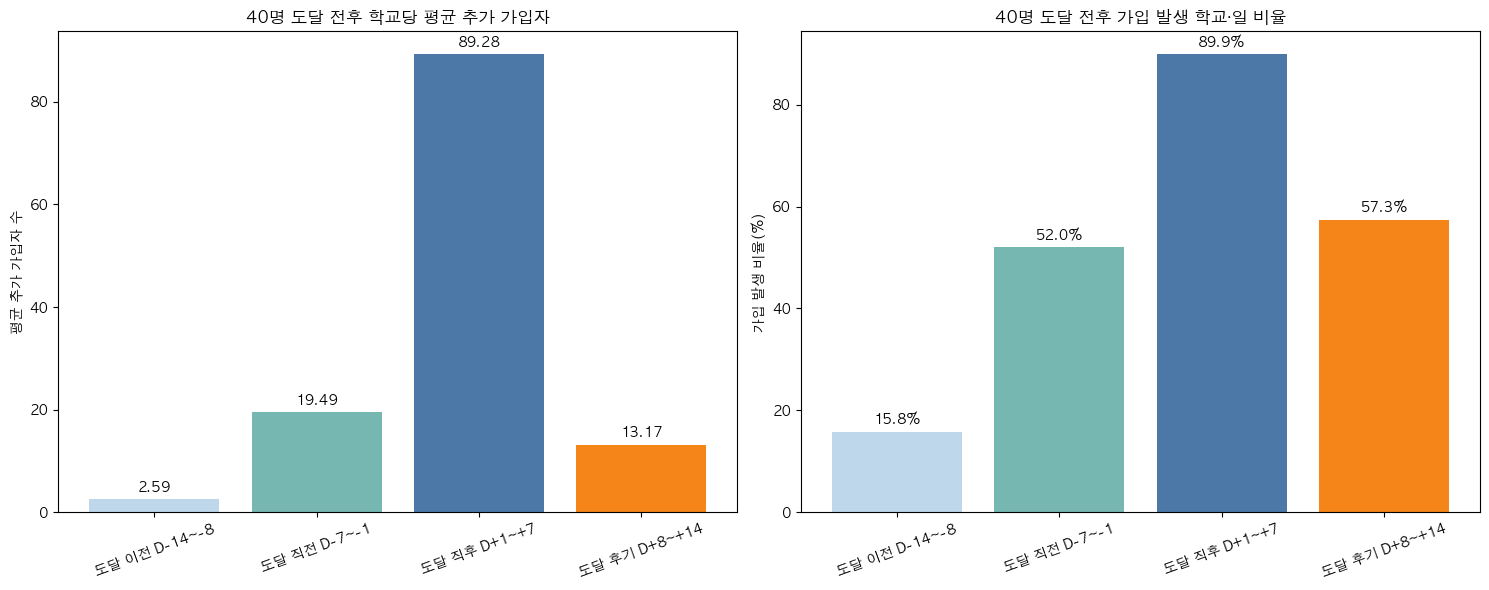

In [12]:
# ============================================================
# 7-3. D0 전후 네 구간 시각화
# ============================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(15, 6)
)

colors = [
    "#BFD7EA",
    "#76B7B2",
    "#4C78A8",
    "#F58518"
]

bars1 = axes[0].bar(
    period_comparison["기간"],
    period_comparison["학교당_평균추가가입자"],
    color=colors
)

axes[0].set_title(
    "40명 도달 전후 학교당 평균 추가 가입자",
    fontweight="bold"
)

axes[0].set_ylabel("평균 추가 가입자 수")
axes[0].tick_params(axis="x", rotation=20)

axes[0].bar_label(
    bars1,
    fmt="%.2f",
    padding=3
)

bars2 = axes[1].bar(
    period_comparison["기간"],
    period_comparison["가입발생_학교일비율(%)"],
    color=colors
)

axes[1].set_title(
    "40명 도달 전후 가입 발생 학교·일 비율",
    fontweight="bold"
)

axes[1].set_ylabel("가입 발생 비율(%)")
axes[1].tick_params(axis="x", rotation=20)

axes[1].bar_label(
    bars2,
    fmt="%.1f%%",
    padding=3
)

plt.tight_layout()
plt.show()

## 학교별  네 구간 데이터 변환

In [13]:
# ============================================================
# 8. 학교별 네 구간 가입자 데이터를 가로 형태로 변환
# ============================================================

school_diffusion = (
    school_period_summary
    .pivot(
        index="school_id",
        columns="기간",
        values="구간추가가입자"
    )
    .reset_index()
)

school_diffusion.columns.name = None

school_diffusion = school_diffusion.rename(
    columns={
        "도달 이전 D-14~-8": "도달이전_D14_D8",
        "도달 직전 D-7~-1": "도달직전_D7_D1",
        "도달 직후 D+1~+7": "첫째주_D1_D7",
        "도달 후기 D+8~+14": "둘째주_D8_D14"
    }
)

period_columns = [
    "도달이전_D14_D8",
    "도달직전_D7_D1",
    "첫째주_D1_D7",
    "둘째주_D8_D14"
]

school_diffusion[period_columns] = (
    school_diffusion[period_columns]
    .fillna(0)
)

# 도달 소요일과 최종 가입자 수 결합
school_diffusion = school_diffusion.merge(
    school_activation[
        [
            "school_id",
            "40명_도달소요일",
            "최종가입자수"
        ]
    ],
    on="school_id",
    how="left"
)

display(school_diffusion.head())

,school_id,도달이전_D14_D8,도달직전_D7_D1,첫째주_D1_D7,둘째주_D8_D14,40명_도달소요일,최종가입자수
0,1,9.00,14.00,7.00,7.00,32.00,93
1,4,0.00,15.00,169.00,4.00,5.00,235
2,5,0.00,19.00,65.00,2.00,7.00,160
3,6,2.00,21.00,132.00,9.00,12.00,197
4,7,1.00,5.00,55.00,4.00,21.00,114


# 네 가지 확산 유형 분류

In [14]:
# ============================================================
# 8-1. 네 가지 확산 유형 분류
# ============================================================

# 도달 후 첫째 주와 둘째 주 중앙값
first_week_median = school_diffusion[
    "첫째주_D1_D7"
].median()

second_week_median = school_diffusion[
    "둘째주_D8_D14"
].median()

conditions = [
    # 첫째 주와 둘째 주 모두 기준 이상
    (
        school_diffusion["첫째주_D1_D7"] >= first_week_median
    )
    & (
        school_diffusion["둘째주_D8_D14"] >= second_week_median
    ),

    # 첫째 주는 높지만 둘째 주는 낮음
    (
        school_diffusion["첫째주_D1_D7"] >= first_week_median
    )
    & (
        school_diffusion["둘째주_D8_D14"] < second_week_median
    ),

    # 첫째 주는 낮지만 둘째 주는 높음
    (
        school_diffusion["첫째주_D1_D7"] < first_week_median
    )
    & (
        school_diffusion["둘째주_D8_D14"] >= second_week_median
    )
]

choices = [
    "지속 확산형",
    "단기 폭발형",
    "후발 확산형"
]

school_diffusion["확산유형"] = np.select(
    conditions,
    choices,
    default="저확산형"
)

print("첫째 주 분류 기준:", first_week_median)
print("둘째 주 분류 기준:", second_week_median)

type_count = (
    school_diffusion["확산유형"]
    .value_counts()
    .rename_axis("확산유형")
    .reset_index(name="학교수")
)

type_count["학교비율(%)"] = (
    type_count["학교수"]
    / type_count["학교수"].sum()
    * 100
).round(2)

display(type_count)

첫째 주 분류 기준: 76.0
둘째 주 분류 기준: 8.0


,확산유형,학교수,학교비율(%)
0,지속 확산형,1382,36.41
1,저확산형,1288,33.93
2,후발 확산형,586,15.44
3,단기 폭발형,540,14.23


# 확산 유형별 특징 요약

In [15]:
# ============================================================
# 8-2. 확산 유형별 가입 특성 요약
# ============================================================

diffusion_summary = (
    school_diffusion
    .groupby("확산유형")
    .agg(
        학교수=("school_id", "nunique"),
        도달직전_평균가입자=("도달직전_D7_D1", "mean"),
        첫째주_평균가입자=("첫째주_D1_D7", "mean"),
        둘째주_평균가입자=("둘째주_D8_D14", "mean"),
        도달소요일_중앙값=("40명_도달소요일", "median"),
        최종가입자수_중앙값=("최종가입자수", "median")
    )
    .reset_index()
)

diffusion_summary["학교비율(%)"] = (
    diffusion_summary["학교수"]
    / diffusion_summary["학교수"].sum()
    * 100
)

numeric_columns = diffusion_summary.select_dtypes(
    include="number"
).columns

diffusion_summary[numeric_columns] = (
    diffusion_summary[numeric_columns]
    .round(2)
)

diffusion_summary = diffusion_summary[
    [
        "확산유형",
        "학교수",
        "학교비율(%)",
        "도달직전_평균가입자",
        "첫째주_평균가입자",
        "둘째주_평균가입자",
        "도달소요일_중앙값",
        "최종가입자수_중앙값"
    ]
].sort_values(
    "학교수",
    ascending=False
)

display(diffusion_summary)

,확산유형,학교수,학교비율(%),도달직전_평균가입자,첫째주_평균가입자,둘째주_평균가입자,도달소요일_중앙값,최종가입자수_중앙값
2,지속 확산형,1382,36.41,18.13,146.25,24.00,8.00,235.00
1,저확산형,1288,33.93,20.73,34.27,2.79,11.00,91.00
3,후발 확산형,586,15.44,22.36,47.09,18.61,8.00,124.00
0,단기 폭발형,540,14.23,16.92,120.51,4.29,9.00,185.00
